In [61]:
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

Импорт библиотек

In [10]:
file_path = 'Кировский продажи СП 2020-2025 (1) (2).xls'   # ← поменяй, если имя файла другое

# Читаем Excel файл
df = pd.read_excel(file_path, sheet_name='TDSheet')

print("Форма данных:", df.shape)
print("Колонки:", df.columns.tolist())
print("\nПервые 5 строк:")
print(df.head())

print(df['Номенклатура'].value_counts().head(5))

Форма данных: (463, 4)
Колонки: ['Месяц год', 'Номенклатура', 'Объем в шт.', 'Объем в кг']

Первые 5 строк:
        Месяц год                                       Номенклатура  \
0  Январь 2020 г.            Кукурузные палочки "Десертные" /60г*40/   
1  Январь 2020 г.             Кукурузные палочки "Сладкие" /140г*18/   
2  Январь 2020 г.     Кукурузные палочки "Сладкие" /500 гр. * 6 шт./   
3  Январь 2020 г.              Кукурузные палочки "Сладкие" /60г*40/   
4  Январь 2020 г.  Кукурузные палочки со вкусом вареного сгущенно...   

   Объем в шт.  Объем в кг  
0         8840         530  
1         2718         381  
2         3078        1539  
3         9080         545  
4         2960         178  
Номенклатура
СТМ Кировский Кукурузные палочки "Десертные" /60г*40/    57
СТМ Кировский Кукурузные палочки "Сладкие" /60г*40/      56
Кукурузные палочки "Десертные" /60г*40/                  53
Кукурузные палочки "Сладкие" /60г*40/                    46
Кукурузные палочки "Сладкие" /14

Для большей точности будем брать самую популярную позицию 

Т.К. самой популярной позицией в выборке это десертные палочки будем считать их

In [11]:
# Приводим названия колонок к удобным
df.columns = ['Месяц_год', 'Номенклатура', 'Объем_шт', 'Объем_кг']

# Преобразуем строки в числа
df['Объем_шт'] = pd.to_numeric(df['Объем_шт'].astype(str).str.replace(',', '').str.strip(), errors='coerce')
df['Объем_кг'] = pd.to_numeric(df['Объем_кг'].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# Парсинг даты
def parse_date(text):
    text = str(text).strip()
    month_map = {
        'Январь':1, 'Февраль':2, 'Март':3, 'Апрель':4, 'Май':5, 'Июнь':6,
        'Июль':7, 'Август':8, 'Сентябрь':9, 'Октябрь':10, 'Ноябрь':11, 'Декабрь':12
    }
    for month_name, month_num in month_map.items():
        if month_name in text:
            year_match = re.search(r'(\d{4})', text)
            year = int(year_match.group(1)) if year_match else None
            if year:
                return pd.Timestamp(year=year, month=month_num, day=1)
    return pd.NaT

df['Дата'] = df['Месяц_год'].apply(parse_date).dt.to_period('M')
df['Год'] = df['Дата'].dt.year
df['Месяц'] = df['Дата'].dt.month
df.drop('Месяц_год', axis=1, inplace=True)

# Фильтруем таблицу: оставляем только строки, где в 'Номенклатура' есть слово 'Десертные'
df = df[df['Номенклатура'].str.contains('Десертные', na=False)]
df.head(5)

,Номенклатура,Объем_шт,Объем_кг,Дата,Год,Месяц
0,"Кукурузные палочки ""Десертные"" /60г*40/",8840,530,2020-01,2020,1
5,"СТМ Кировский Кукурузные палочки ""Десертные"" /...",14680,881,2020-01,2020,1
7,"Кукурузные палочки ""Десертные"" /60г*40/",16600,996,2020-02,2020,2
12,"СТМ Кировский Кукурузные палочки ""Десертные"" /...",13960,838,2020-02,2020,2
14,"Кукурузные палочки ""Десертные"" /60г*40/",9000,540,2020-03,2020,3


Переводим в более понятный формат для машины

In [12]:
print(df['Номенклатура'].value_counts())

Номенклатура
СТМ Кировский Кукурузные палочки "Десертные" /60г*40/    57
Кукурузные палочки "Десертные" /60г*40/                  53
СТМ Кировский Кукурузные палочки "Десертные" /60г*50/    12
Кукурузные палочки "Десертные" /60г*50/                  10
Name: count, dtype: int64


Сейчас остались только десертные, но осталось запарсить их вес и количество в упаковке

In [13]:
def pars(self):
    if "/60г*40/" in self:
        return 40
    elif "/60г*50/" in self:
        return 50

df["Количество_в_упаковки"] = df['Номенклатура'].apply(pars)
df["Объем_кг_упаковки"] = 60 * df["Количество_в_упаковки"] / 1000

df
    

,Номенклатура,Объем_шт,Объем_кг,Дата,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки
0,"Кукурузные палочки ""Десертные"" /60г*40/",8840,530,2020-01,2020,1,40,2.4
5,"СТМ Кировский Кукурузные палочки ""Десертные"" /...",14680,881,2020-01,2020,1,40,2.4
7,"Кукурузные палочки ""Десертные"" /60г*40/",16600,996,2020-02,2020,2,40,2.4
12,"СТМ Кировский Кукурузные палочки ""Десертные"" /...",13960,838,2020-02,2020,2,40,2.4
14,"Кукурузные палочки ""Десертные"" /60г*40/",9000,540,2020-03,2020,3,40,2.4
...,...,...,...,...,...,...,...,...
449,"СТМ Кировский Кукурузные палочки ""Десертные"" /...",11520,691,2025-06,2025,6,40,2.4
451,"Кукурузные палочки ""Десертные"" /60г*40/",10560,634,2025-07,2025,7,40,2.4
455,"СТМ Кировский Кукурузные палочки ""Десертные"" /...",8640,518,2025-07,2025,7,40,2.4
457,"Кукурузные палочки ""Десертные"" /60г*40/",4800,288,2025-08,2025,8,40,2.4


In [14]:
df['Объем_кг'] = df.groupby('Дата')['Объем_кг'].transform('sum')
df['Объем_шт'] = df.groupby('Дата')['Объем_шт'].transform('sum')

df.drop('Номенклатура', axis=1, inplace=True)

df = df.drop_duplicates().reset_index(drop=True)

df

,Объем_шт,Объем_кг,Дата,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки
0,23520,1411,2020-01,2020,1,40,2.4
1,30560,1834,2020-02,2020,2,40,2.4
2,20120,1207,2020-03,2020,3,40,2.4
3,53160,3190,2020-04,2020,4,40,2.4
4,36280,2177,2020-05,2020,5,40,2.4
...,...,...,...,...,...,...,...
65,8640,519,2025-04,2025,4,40,2.4
66,19200,1152,2025-05,2025,5,40,2.4
67,28800,1728,2025-06,2025,6,40,2.4
68,19200,1152,2025-07,2025,7,40,2.4


Теперь вся информация в таблице

# EDA

В данном блоке нужно провести анализ таблице и вывости анамалии

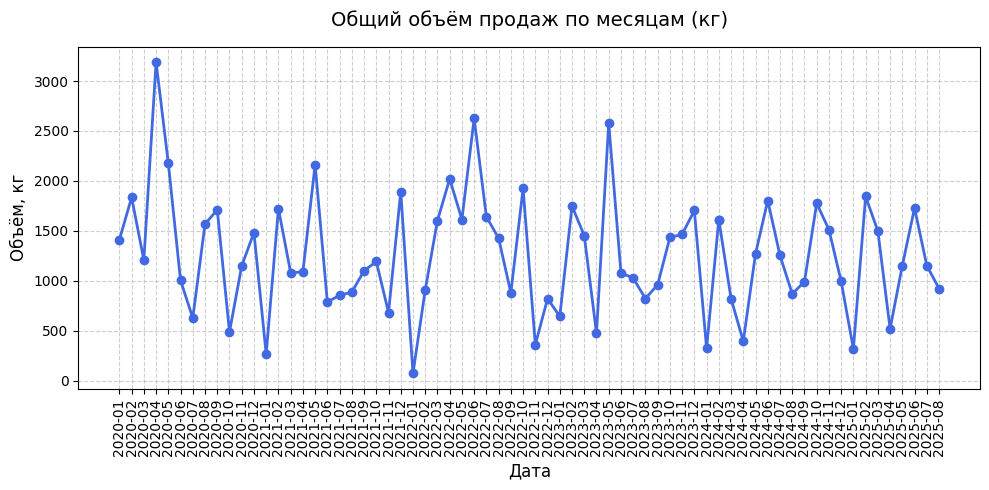

,Дата,Объем_кг,Дата_стр
3,2020-04,3190,2020-04
24,2022-01,72,2022-01


In [15]:
plt.figure(figsize=(10, 5))

# 1. берем необходимое
df_grouped = df[['Дата', 'Объем_кг']]

#Лучше временно перевести в строку для графика:
df_grouped['Дата_стр'] = df_grouped['Дата'].astype(str)

# 2. Строим график
plt.plot(df_grouped['Дата_стр'], df_grouped['Объем_кг'], marker='o', linewidth=2, color='royalblue')

plt.title('Общий объём продаж по месяцам (кг)', fontsize=14, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Объём, кг', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)  # Сделаем сетку чуть помягче

# Поворачиваем подписи дат, чтобы они не налезали друг на друга, если их много
plt.xticks(rotation=90) 

plt.tight_layout()  # Автоматически подправит отступы, чтобы подписи не обрезались
plt.show()

df_grouped[(df_grouped['Дата'] == '2022-01') | (df_grouped['Дата'] == '2020-04')]



Ключевые аномалии
Исторический максимум: Зафиксирован в начале 2020 года — объем продаж подскочил выше 3100 кг. Это почти в 2-3 раза выше средней нормы.

Крупные всплески: Также заметны сильные пики в середине 2022 года, весной 2023 года.

Абсолютный минимум: Самый жесткий спад произошел в 2022 год — продажи упали практически до нуля.


Поэтому что бы эти данные не мешали их нужно убрать

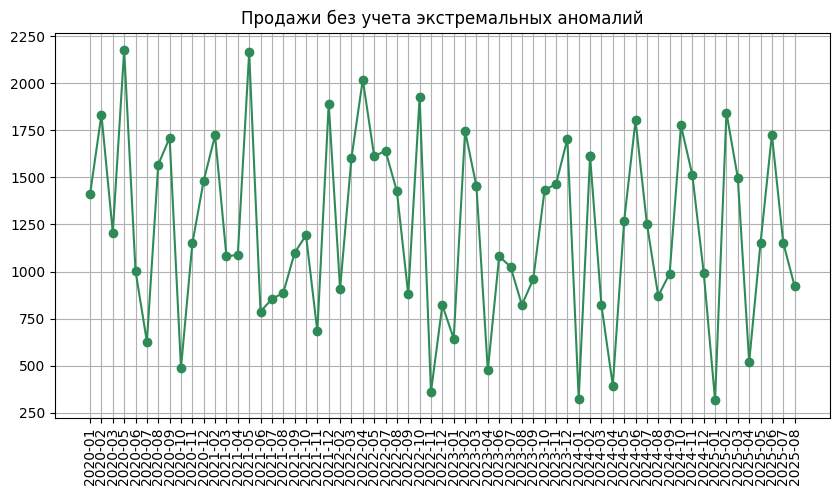

In [16]:
# Оставляем только те месяцы, где объем продаж в пределах нормы
df_normal = df_grouped[(df_grouped['Объем_кг'] >= 300) & (df_grouped['Объем_кг'] <= 2500)]

# Строим новый график
plt.figure(figsize=(10, 5))
plt.plot(df_normal['Дата_стр'], df_normal['Объем_кг'], marker='o', color='seagreen')
plt.title('Продажи без учета экстремальных аномалий')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Теперь все более предсказуемо и не так много дат убранно

Теперь надо перенести в основной dataframe 

In [17]:

# Фильтруем df по этой колонке
df = df[(df['Объем_кг'] >= 300) & (df['Объем_кг'] <= 2500)].copy()

df

,Объем_шт,Объем_кг,Дата,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки
0,23520,1411,2020-01,2020,1,40,2.4
1,30560,1834,2020-02,2020,2,40,2.4
2,20120,1207,2020-03,2020,3,40,2.4
4,36280,2177,2020-05,2020,5,40,2.4
5,16720,1003,2020-06,2020,6,40,2.4
...,...,...,...,...,...,...,...
65,8640,519,2025-04,2025,4,40,2.4
66,19200,1152,2025-05,2025,5,40,2.4
67,28800,1728,2025-06,2025,6,40,2.4
68,19200,1152,2025-07,2025,7,40,2.4


На этом этапе можно сравнить динамику продаж по месяцам за каждый год

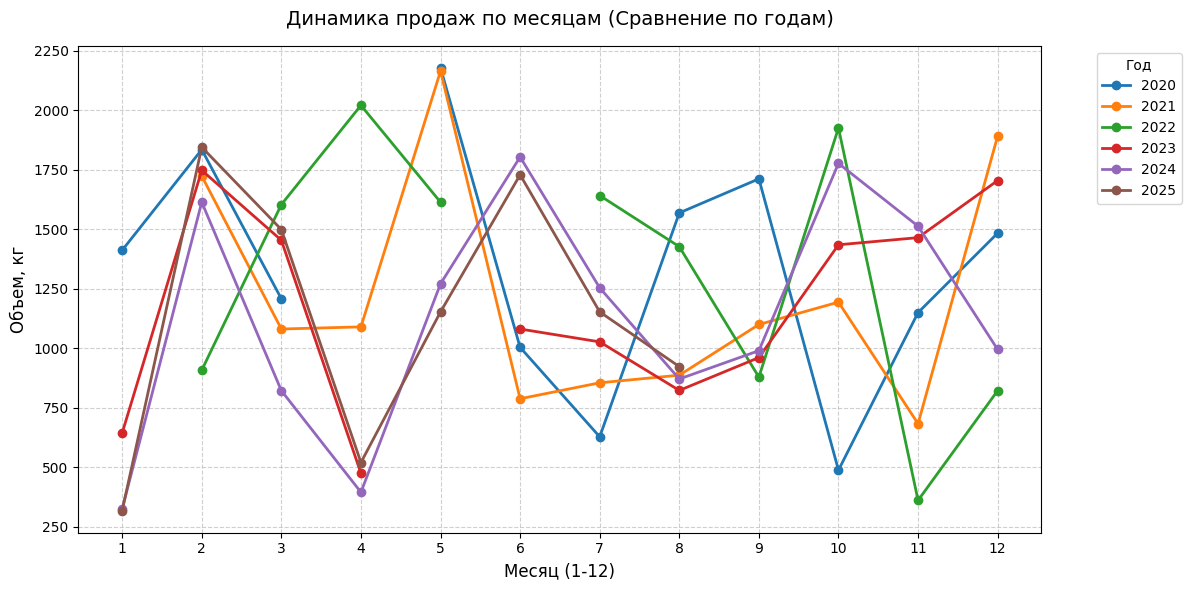

In [18]:
df_grouped_month = df[['Месяц', 'Объем_кг', 'Год']].copy()
pivot_df = df_grouped_month.pivot_table(index='Месяц', columns='Год', values='Объем_кг')
plt.figure(figsize=(12, 6))
pivot_df.plot(ax=plt.gca(), marker='o', linewidth=2)
plt.title('Динамика продаж по месяцам (Сравнение по годам)', fontsize=14, pad=15)
plt.xlabel('Месяц (1-12)', fontsize=12)
plt.ylabel('Объем, кг', fontsize=12)
plt.xticks(range(1, 13)) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Год', bbox_to_anchor=(1.05, 1), loc='upper left') # Выносим легенду правее
plt.tight_layout() # Чтобы легенда не обрезалась
plt.show()

Точной сезонности не наблюдается.

Но есть схожие пики например:

* февраль - аномальный всплеск продаж
* май - аномальное падение продаж

Но вывести метрику на основе полученных данных возможно


In [19]:
# Нам нужно заглянуть в будущее на 1 шаг вперед с помощью shift(-1)
df['Вырос_в_следующем'] = (df['Объем_кг'].shift(-1) > df['Объем_кг']).astype(int)

# Общий шанс по всей выборке (просто среднее от единичек и нулей)
total_chance = df['Вырос_в_следующем'].mean()

print(f"Общий шанс на то, что следующий месяц вырастет: {total_chance * 100:.1f}%")
df

Общий шанс на то, что следующий месяц вырастет: 50.8%


,Объем_шт,Объем_кг,Дата,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки,Вырос_в_следующем
0,23520,1411,2020-01,2020,1,40,2.4,1
1,30560,1834,2020-02,2020,2,40,2.4,0
2,20120,1207,2020-03,2020,3,40,2.4,1
4,36280,2177,2020-05,2020,5,40,2.4,0
5,16720,1003,2020-06,2020,6,40,2.4,0
...,...,...,...,...,...,...,...,...
65,8640,519,2025-04,2025,4,40,2.4,1
66,19200,1152,2025-05,2025,5,40,2.4,1
67,28800,1728,2025-06,2025,6,40,2.4,0
68,19200,1152,2025-07,2025,7,40,2.4,0


Данная метрика оценивает вырастут ли продажи в след  месяце

А общий шанс говорит только о том что шанс этот почти одинаковый

In [20]:
df['MoM_Growth'] = df['Объем_кг'].pct_change() * 100

df

,Объем_шт,Объем_кг,Дата,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки,Вырос_в_следующем,MoM_Growth
0,23520,1411,2020-01,2020,1,40,2.4,1,NaN
1,30560,1834,2020-02,2020,2,40,2.4,0,29.978738
2,20120,1207,2020-03,2020,3,40,2.4,1,-34.187568
4,36280,2177,2020-05,2020,5,40,2.4,0,80.364540
5,16720,1003,2020-06,2020,6,40,2.4,0,-53.927423
...,...,...,...,...,...,...,...,...,...
65,8640,519,2025-04,2025,4,40,2.4,1,-65.353805
66,19200,1152,2025-05,2025,5,40,2.4,1,121.965318
67,28800,1728,2025-06,2025,6,40,2.4,0,50.000000
68,19200,1152,2025-07,2025,7,40,2.4,0,-33.333333


Добавил колонку с процентами изменения на след месяц

In [21]:
df.corr(numeric_only=True)

,Объем_шт,Объем_кг,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки,Вырос_в_следующем,MoM_Growth
Объем_шт,1.000000,1.000000,-0.123057,-0.018170,-0.100776,-0.100776,-0.591894,0.523987
Объем_кг,1.000000,1.000000,-0.122794,-0.018193,-0.100787,-0.100787,-0.591999,0.524120
Год,-0.123057,-0.122794,1.000000,-0.179668,0.200609,0.200609,-0.199370,0.095172
Месяц,-0.018170,-0.018193,-0.179668,1.000000,0.035467,0.035467,-0.001671,-0.060245
Количество_в_упаковки,-0.100776,-0.100787,0.200609,0.035467,1.000000,1.000000,0.034091,-0.113367
Объем_кг_упаковки,-0.100776,-0.100787,0.200609,0.035467,1.000000,1.000000,0.034091,-0.113367
Вырос_в_следующем,-0.591894,-0.591999,-0.199370,-0.001671,0.034091,0.034091,1.000000,-0.278140
MoM_Growth,0.523987,0.524120,0.095172,-0.060245,-0.113367,-0.113367,-0.278140,1.000000


Матрица корреляции

# Feature Engineering

In [22]:
# сортируем по дате
df = df.sort_values('Дата').copy()
df['Дата_стр'] = df['Дата'].astype(str)

# Создаем лаги (модель будет знать, что происходило в прошлых месяцах)
df['Lag_1'] = df['Объем_кг'].shift(1)  # Прошлый месяц
df['Lag_2'] = df['Объем_кг'].shift(2)  # 2 месяца назад
df['Lag_12'] = df['Объем_кг'].shift(12) # Тот же месяц год назад (важно для сезонности)

# Скользящее среднее за 3 месяца (сглаженный тренд)
df['Rolling_Mean_3'] = df['Объем_кг'].shift(1).rolling(window=3).mean()

# Из-за сдвигов (shift) первые 12 строк будут с NaN (так как для них нет истории за прошлый год). Удаляем их.
df.dropna(inplace=True)

In [23]:
df

,Объем_шт,Объем_кг,Дата,Год,Месяц,Количество_в_упаковки,Объем_кг_упаковки,Вырос_в_следующем,MoM_Growth,Дата_стр,Lag_1,Lag_2,Lag_12,Rolling_Mean_3
14,18000,1080,2021-03,2021,3,40,2.4,1,-37.318630,2021-03,1723.0,1483.0,1411.0,1451.666667
15,18160,1089,2021-04,2021,4,40,2.4,1,0.833333,2021-04,1080.0,1723.0,1834.0,1428.666667
16,36080,2164,2021-05,2021,5,40,2.4,0,98.714417,2021-05,1089.0,1080.0,1207.0,1297.333333
17,13120,787,2021-06,2021,6,40,2.4,1,-63.632163,2021-06,2164.0,1089.0,2177.0,1444.333333
18,14240,854,2021-07,2021,7,40,2.4,1,8.513342,2021-07,787.0,2164.0,1003.0,1346.666667
19,14760,886,2021-08,2021,8,40,2.4,1,3.747073,2021-08,854.0,787.0,627.0,1268.333333
20,18320,1099,2021-09,2021,9,40,2.4,1,24.040632,2021-09,886.0,854.0,1568.0,842.333333
21,19880,1193,2021-10,2021,10,40,2.4,0,8.553230,2021-10,1099.0,886.0,1711.0,946.333333
22,11360,682,2021-11,2021,11,40,2.4,1,-42.833194,2021-11,1193.0,1099.0,487.0,1059.333333
23,31520,1891,2021-12,2021,12,40,2.4,0,177.272727,2021-12,682.0,1193.0,1149.0,991.333333


# Обучение

Готовим данные

In [24]:
features = ['Месяц', 'Год', 'Lag_1', 'Lag_2', 'Lag_12',
            'Rolling_Mean_3', 'Количество_в_упаковки',
            'Объем_кг_упаковки',]

X = df[features]
y = df['Объем_кг']

In [25]:
# Допустим, оставляем последние 6 месяцев на тест для проверки модели
test_size = 6

X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

In [50]:
df_prophet = pd.DataFrame()
df_prophet['ds'] = pd.to_datetime(df['Дата_стр']) # Дата
df_prophet['y'] = df['Объем_кг']                  # Целевой объем

# Сортируем по времени
df_prophet = df_prophet.sort_values('ds').reset_index(drop=True)

# 2. Делим на train/test (последние 6 месяцев на тест)
train_data = df_prophet.iloc[:-test_size]
test_data = df_prophet.iloc[-test_size:]

# 3. Обучаем Prophet
model_p = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=False, 
    daily_seasonality=False,
    changepoint_prior_scale=0.1, # более гибкий тренд
    seasonality_prior_scale=1000 # более выраженная сезонность
)

model_p.add_country_holidays(country_name='RU') 

model_p.fit(train_data)

# 4. Прогноз в будущее
future = model_p.make_future_dataframe(periods=test_size, freq='MS')
forecast = model_p.predict(future)

14:25:33 - cmdstanpy - INFO - Chain [1] start processing
14:25:33 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
# 1. Берем реальные значения из test_data
y_true = test_data['y'].values

# 2. Вытаскиваем предсказания Prophet (yhat) за этот же период
# Отрезаем последние 6 строк из таблицы forecast
y_pred_p = forecast.iloc[-test_size:]['yhat'].values

# 3. Считаем метрики

mape_p = mean_absolute_percentage_error(y_true, y_pred_p) * 100  # Переводим в проценты

print(f"--- МЕТРИКИ НА ТЕСТОВОМ ОТРЕЗКЕ ---")
print(f"Процентная ошибка (MAPE): {mape:.1f}%")

--- МЕТРИКИ НА ТЕСТОВОМ ОТРЕЗКЕ ---
Процентная ошибка (MAPE): 32.2%


In [59]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=30,
    random_state=42,
    verbose=-1 # Отключаем лишние логи в консоли
)

lgb_model.fit(X_train, y_train)

# 6. Делаем прогноз
y_pred_lgb = lgb_model.predict(X_test)

# 7. Считаем ошибку MAPE
mape_lgb = mean_absolute_percentage_error(y_test, y_pred_lgb) * 100
print(f"--- РЕЗУЛЬТАТ LIGHTGBM ---")
print(f"Ошибка MAPE на тесте: {mape_lgb:.1f}%")

--- РЕЗУЛЬТАТ LIGHTGBM ---
Ошибка MAPE на тесте: 33.0%


In [41]:
# 1. Инициализируем модель (передаем только y_train, так как это одномерный ряд)
model_s = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12),
                  enforce_stationarity=False, enforce_invertibility=False)

# 2. Обучаем
results_s = model_s.fit(disp=False)

# 3. Делаем прогноз на следующие 6 месяцев (размер тестовой выборки)
# Метод forecast сам поймет, с какой даты продолжить
y_pred_s = results_s.forecast(steps=test_size)

# 4. Считаем ошибку MAPE именно для SARIMAX
mape_s = mean_absolute_percentage_error(y_test, y_pred_s) * 100

print(f"--- РЕЗУЛЬТАТ SARIMAX ---")
print(f"Ошибка MAPE на тесте: {mape_s:.1f}%")

--- РЕЗУЛЬТАТ SARIMAX ---
Ошибка MAPE на тесте: 10.2%


In [47]:
model_hw = ExponentialSmoothing(y_train, trend='add', seasonal='add',
                                seasonal_periods=12, damped_trend=True).fit()

y_pred_hw = model_hw.forecast(test_size)

mape_hw = mean_absolute_percentage_error(y_test, y_pred_hw) * 100

print(f"--- РЕЗУЛЬТАТ holt-winter ---")
print(f"Ошибка MAPE на тесте: {mape_hw:.1f}%")

--- РЕЗУЛЬТАТ holt-winter ---
Ошибка MAPE на тесте: 21.5%


In [66]:
# 1. Нейросетям нужен одинаковый масштаб фич, поэтому делаем стандартизацию
scaler = StandardScaler()

# Обучаем scaler на тренировочных фичах и трансформируем их
X_train_scaled = scaler.fit_transform(X_train)
# Тестовые фичи ТОЛЬКО трансформируем (не обучаем на них scaler!)
X_test_scaled = scaler.transform(X_test)

# 2. Создаем нейросеть
# hidden_layer_sizes=(64, 32) означает два скрытых слоя: первый на 64 нейрона, второй на 32.
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    solver='adam', 
    max_iter=1000, 
    random_state=42
)

# 3. Обучаем нейронку
nn_model.fit(X_train_scaled, y_train)

# 4. Делаем честный прогноз
y_pred_nn = nn_model.predict(X_test_scaled)

# 5. Считаем ошибку
mape_nn = mean_absolute_percentage_error(y_test, y_pred_nn) * 100
print(f"--- РЕЗУЛЬТАТ НЕЙРОСЕТИ ---")
print(f"Ошибка MAPE на тесте: {mape_nn:.1f}%")

--- РЕЗУЛЬТАТ НЕЙРОСЕТИ ---
Ошибка MAPE на тесте: 15.3%


In [53]:
# --- 1. СБОР ПРОГНОЗОВ ---
# Нам нужен горизонт в последние 6 месяцев
dates_test = test_data['ds'] if 'test_data' in locals() else df_ml.iloc[-test_size:]['Дата']
y_true = y_test.values

In [69]:
# --- 2. РАСЧЕТ МЕТРИК MAPE ---
mae_lgb = mean_absolute_error(y_true, y_pred_lgb)
mae_s = mean_absolute_error(y_true, y_pred_s)
mae_hw = mean_absolute_error(y_true, y_pred_hw)
mae_p = mean_absolute_error(y_true, y_pred_p)
mae_nn = mean_absolute_error(y_test, y_pred_nn)

mape_lgb = mean_absolute_percentage_error(y_true, y_pred_lgb) * 100
mape_s = mean_absolute_percentage_error(y_true, y_pred_s) * 100
mape_hw = mean_absolute_percentage_error(y_true, y_pred_hw) * 100
mape_p = mean_absolute_percentage_error(y_true, y_pred_p) * 100
mape_nn = mean_absolute_percentage_error(y_test, y_pred_nn) * 100

# --- 3. СРАВНИТЕЛЬНАЯ ТАБЛИЦА В КОНСОЛЬ ---
df_metrics = pd.DataFrame({
    'Модель': ['LightGBM', 'SARIMAX', 'Holt-Winters', 'Prophet', 'MLPRegressor'],
    'Ошибка MAPE (%)': [f"{mape_lgb:.2f}%", f"{mape_s:.2f}%", f"{mape_hw:.2f}%", f"{mape_p:.2f}%", f"{mape_nn:.2f}%"],
    'Ошибка MAE КГ' : [mae_lgb, mae_s, mae_hw, mae_p, mae_nn]
}).sort_values(by='Ошибка MAPE (%)')

print("\n========= СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ =========")
print(df_metrics.to_string(index=False))
print("==============================================\n")


========= СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ =========
      Модель Ошибка MAPE (%)  Ошибка MAE КГ
     SARIMAX          10.17%     141.402070
MLPRegressor          15.28%     119.031852
Holt-Winters          21.49%     173.475245
     Prophet          32.23%     307.362341
    LightGBM          33.02%     269.483106



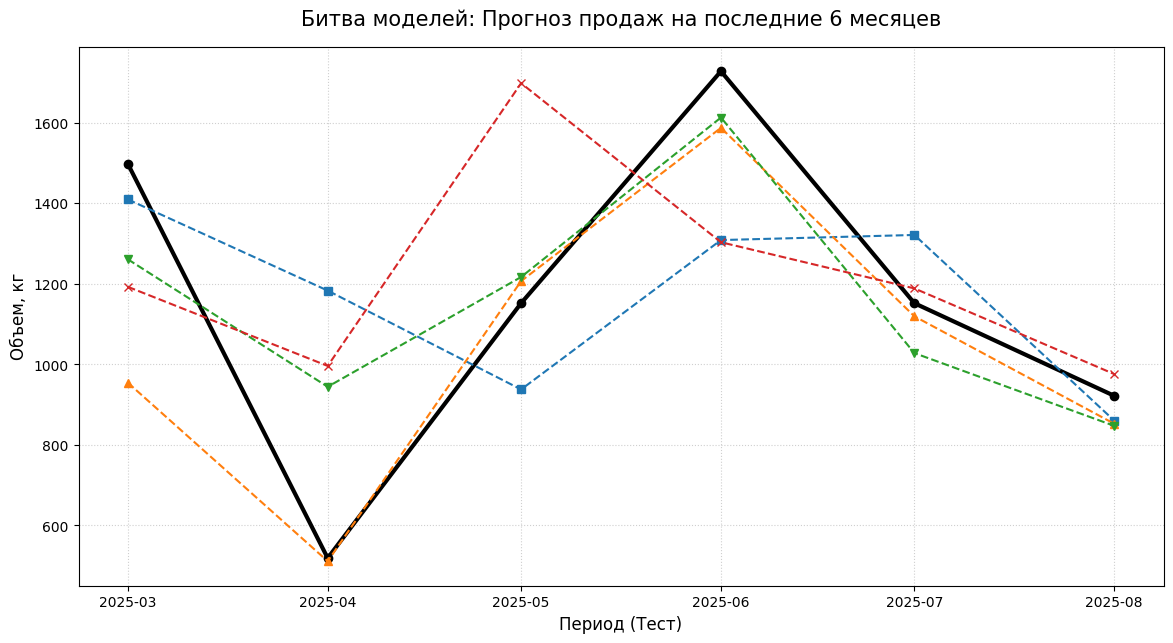

In [62]:
# --- 4. ВИЗУАЛИЗАЦИЯ (ГРАФИК СРАВНЕНИЯ) ---
plt.figure(figsize=(14, 7))

# Жирная черная линия — это реальные продажи (Факт)
plt.plot(dates_test, y_true, marker='o', color='black', linewidth=3, label='РЕАЛЬНОСТЬ (Факт)')

# Тонкие цветные линии — прогнозы наших моделей
plt.plot(dates_test, y_pred_lgb, marker='s', linestyle='--', linewidth=1.5, label=f'LightGBM (MAPE: {mape_lgb:.1f}%)')
plt.plot(dates_test, y_pred_s, marker='^', linestyle='--', linewidth=1.5, label=f'SARIMAX (MAPE: {mape_s:.1f}%)')
plt.plot(dates_test, y_pred_hw, marker='v', linestyle='--', linewidth=1.5, label=f'Holt-Winters (MAPE: {mape_hw:.1f}%)')
plt.plot(dates_test, y_pred_p, marker='x', linestyle='--', linewidth=1.5, label=f'Prophet (MAPE: {mape_p:.1f}%)')

# Настройка стиля графика
plt.title('Битва моделей: Прогноз продаж на последние 6 месяцев', fontsize=15, pad=15)
plt.xlabel('Период (Тест)', fontsize=12)
plt.ylabel('Объем, кг', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)